# Занятие 3: Статистический вывод

## Зачем мы это делаем

По сути, конкретно здесь вы не делаем статистический вывод как таковой. Вместо этого мы решаем другую практическую задачу - **обнаружение аномалий во временном ряду**. Эта задача часто встречается на практике и чаще всего реализуется в режиме онлайн, но можно делать и постфактум.

Фактически мы здесь используем инструментарий доверительных интервалов, чтобы определить критерий "аномальности". Учитывая при этом тот факт, что мы работаем с временным рядом - чередой значений, меняющихся во времени и зависящих друг от друга.

Естественно, есть и [другие способы](https://github.com/rob-med/awesome-TS-anomaly-detection) детекции аномалий - просто этот самый простой и наиболее тематический. 

In [1]:
#всё как обычно
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc={'figure.figsize':(12,6)}, style="whitegrid")

# П Р О Е К Т

Представьте, что вы работаете аналитиком в компании, которая занимается арендой велосипедов. Коллега из офиса в Лондоне прислал вам данные за два года: с 4 января 2015 по 3 января 2017. Вам предстоит изучить динамику числа аренд, наличие связей с погодными условиями и выходными, а также объяснить несколько аномалий на графике. 

- timestamp – дата и время (точность до часа)
- cnt – количество аренд велосипедов за этот час
- t1 – температура, в С
- t2 – температура "ощущается как", в С 
- hum – влажность (%)
- wind_speed – скорость ветра, км/ч
- weather_code – погодные условия
    - 1 – ясно (SKC)
    - 2 – преимущественно ясно / встречаются отдельные облака (SCT)
    - 3 – облачно / значительные облака (BKN)
    - 4 – пасмурно (OVC)
    - 7 – небольшой дождь Rain/ light Rain shower/ Light rain 
    - 10 – дождь с грозой
    - 26 – снегопад 
    - 94 – ледяной туман (да, такое бывает!)
- isholiday – является ли день праздником (1 – праздник, 0 – нет)
- isweekend –  является ли день выходным (1 – выходной, 0 – нет)
- season - метеорологический сезон (0 – весна, 1 – лето,2 – осень, 3 – зима)


## 1 

Загрузите данные, проверьте число наблюдений и столбцов. Убедитесь, что типы данных были интерпретированы pandas правильно. При необходимости – приведите переменные к нужным типам. 

Есть ли в данных пропущенные значения?

In [2]:
df = pd.read_csv('https://getfile.dokpub.com/yandex/get/https://disk.yandex.ru/d/c4t6B6OFDANVbg', 
                 parse_dates=['timestamp'])

In [3]:
df.isna().sum()

timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

In [4]:
df.shape

(17414, 10)

In [5]:
df.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [6]:
df.describe()

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468091,11.520836,72.324954,15.913063,2.722752,0.022051,0.285403,1.492075
std,1085.108068,5.571818,6.615145,14.313186,7.894570,2.341163,0.146854,0.451619,1.118911
min,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,7860.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000


In [7]:
df.dtypes

timestamp       datetime64[ns]
cnt                      int64
t1                     float64
t2                     float64
hum                    float64
wind_speed             float64
weather_code           float64
is_holiday             float64
is_weekend             float64
season                 float64
dtype: object

## 2

Для начала попробуем посмотреть на число поездок по датам и времени. Постройте график, где:

- по оси x – дата (timestamp)
- по оси y – число поездок (cnt)

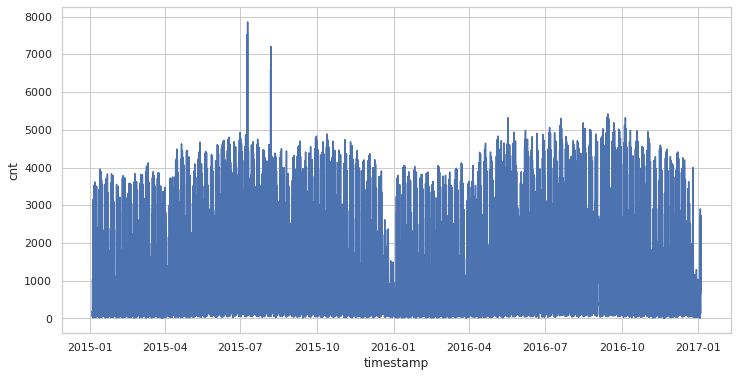

In [8]:
sns.lineplot(x="timestamp", y="cnt", data=df)

## 3
Отлично! Предположим, что данные действительно нужно немного преобразовать. В этом нам поможет resample, с которым вы могли столкнуться в дополнительных темах pandas. Этот метод позволяет преобразовать данные и применить к какому-либо столбцу другой метод (напр. sum). Так можно рассчитать показатели, например, за весь день или месяц, имея данные с точностью до минут. Например, посчитать сумму показателя по дням, имея данные по часам, можно следующим образом:

    data.resample(rule='D').column_name.sum()
    data.resample(rule='D').agg({'column_name':'sum'})
    
Агрегируйте число поездок по дням и визуализируйте результат. Что вы можете сказать о полученном графике?

- Встречаются как очень резкие скачки числа аренд, так и падения
- Зимой число аренд меньше, чем летом
- Максимальное число аренд за день составляет более 70 000

In [3]:
df.sort_values(by='timestamp', inplace=True) #сортируем на всякий случай
df.set_index('timestamp', drop=False, inplace=True) #переносим даты в индекс, но из данных не выкидываем

In [10]:
df.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
timestamp,,,,,,,,,,
2015-01-04 00:00:00,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
2015-01-04 01:00:00,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2015-01-04 02:00:00,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
2015-01-04 03:00:00,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
2015-01-04 04:00:00,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


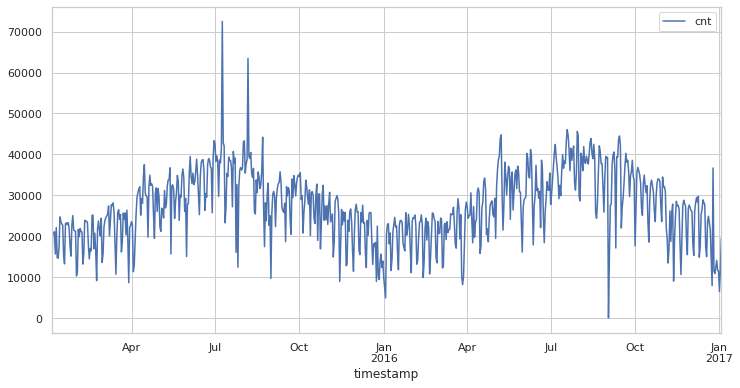

In [11]:
df.resample('D').agg({'cnt':'sum'}).plot() #суммарные аренды по дням

In [12]:
#что было бы с групбаем

df["date"] = df.timestamp.dt.date #извлекаем дату
df.date

timestamp
2015-01-04 00:00:00    2015-01-04
2015-01-04 01:00:00    2015-01-04
2015-01-04 02:00:00    2015-01-04
2015-01-04 03:00:00    2015-01-04
2015-01-04 04:00:00    2015-01-04
                          ...    
2017-01-03 19:00:00    2017-01-03
2017-01-03 20:00:00    2017-01-03
2017-01-03 21:00:00    2017-01-03
2017-01-03 22:00:00    2017-01-03
2017-01-03 23:00:00    2017-01-03
Name: date, Length: 17414, dtype: object

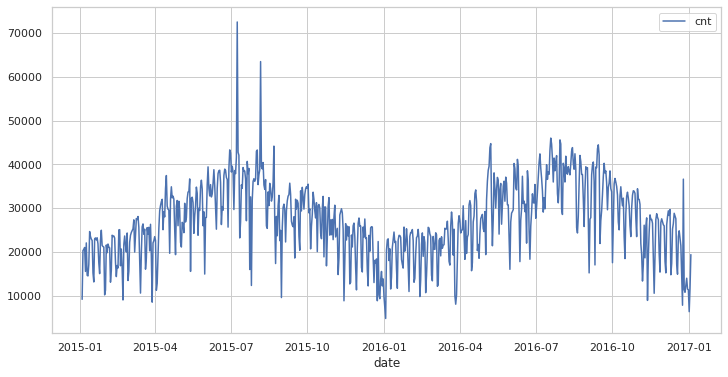

In [13]:
df.groupby('date').agg({'cnt':'sum'}).plot()

## 4
Итак, вы обнаружили на графике некоторые скачки. Давайте проверим, что же могло произойти в тот день 🤔.

Для этого разделим дальнейшие действия на несколько этапов:

- сначала посчитаем скользящее среднее, чтобы сгладить ряд
- далее – разницу между наблюдаемыми и сглаженными значениями
- определим верхние и нижние границы 99% доверительного интервала 
- найдем причины аномалий!

На данном шаге возьмите агрегированные данные по дням с предыдущего шага и посчитайте скользящее среднее с окном 3. В качестве ответа укажите полученное число аренд за 2015-07-09, округлив значение до целого.

In [4]:
df_by_day = df.resample('D').cnt.sum().reset_index()  
df_by_day

,timestamp,cnt
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
726,2016-12-30,11566
727,2016-12-31,11424
728,2017-01-01,6421
729,2017-01-02,11823


In [5]:
#скользящее среднее
df_by_day_roll = df.resample('D').cnt.sum().rolling(window=3).mean().reset_index()
df_by_day_roll

,timestamp,cnt
0,2015-01-04,NaN
1,2015-01-05,NaN
2,2015-01-06,16739.666667
3,2015-01-07,20683.000000
4,2015-01-08,19092.666667
...,...,...
726,2016-12-30,12682.000000
727,2016-12-31,12347.333333
728,2017-01-01,9803.666667
729,2017-01-02,9889.333333


In [6]:
#как работает скользящее среднее
np.mean([20613, 20372, 9234])

16739.666666666668

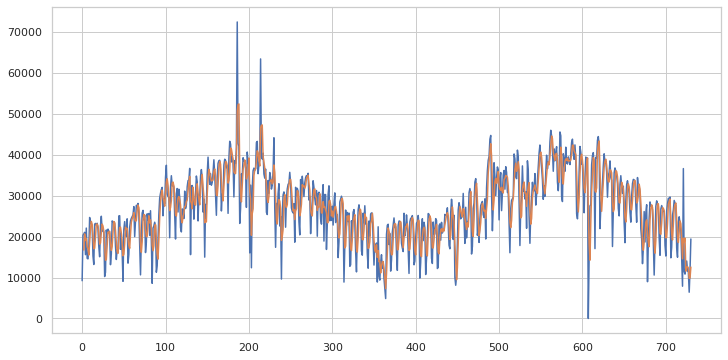

In [7]:
#нарисуем в одних координатах
df_by_day.cnt.plot()
df_by_day_roll.cnt.plot() 

In [8]:
df_by_day_roll.query("timestamp == '2015-07-09'") #берём нужный день

,timestamp,cnt
186,2015-07-09,50705.0


## 5

Теперь посчитайте разницу между наблюдаемыми и подсчитанными значениями. Далее – примените функцию для подсчета стандартного отклонения. Например:

    c = a - b
    std = np.std(c)

В качестве ответа введите полученное стандартное отклонение, округленное до 2 знаков после точки.

In [9]:
round(np.std(df_by_day['cnt'] - df_by_day_roll['cnt']), 2) ###

4558.59

In [10]:
std = np.std(df_by_day['cnt'] - df_by_day_roll['cnt'])

## 6

Теперь определим границы интервалов. Для этого нужно взять данные, полученные при расчете скользящего среднего, и создать следующие объекты:

- upper_bound – верхняя граница; к средним прибавляем 2.576 * std
- lower_bound – нижняя граница; вычитаем 2.576 * std

Полученные значения запишите в новые столбцы датафрейма с агрегированными данными.

Чему равно значение верхней границы для последнего наблюдения? Ответ укажите с точностью до 2 знаков после точки.

In [11]:
upper_bound = df_by_day_roll.cnt + (2.576 * std)
lower_bound = df_by_day_roll.cnt - (2.576 * std)

In [12]:
df_by_day['upper_bound'] = upper_bound
df_by_day['lower_bound'] = lower_bound

In [13]:
df_by_day

,timestamp,cnt,upper_bound,lower_bound
0,2015-01-04,9234,NaN,NaN
1,2015-01-05,20372,NaN,NaN
2,2015-01-06,20613,28482.585854,4996.747479
3,2015-01-07,21064,32425.919188,8940.080812
4,2015-01-08,15601,30835.585854,7349.747479
...,...,...,...,...
726,2016-12-30,11566,24424.919188,939.080812
727,2016-12-31,11424,24090.252521,604.414146
728,2017-01-01,6421,21546.585854,-1939.252521
729,2017-01-02,11823,21632.252521,-1853.585854


## 7
И наконец – изучим аномально высокие значения. Сначала выведите наблюдения, для которых наблюдаемые значения оказались больше верхней границы доверительного интервала. В какой день значения оказались наибольшими? Укажите дату в формате 2020-12-31

In [14]:
df_by_day[df_by_day.cnt > df_by_day.upper_bound]

,timestamp,cnt,upper_bound,lower_bound
186,2015-07-09,72504,62447.919188,38962.080812
214,2015-08-06,63468,58370.252521,34884.414146
609,2016-09-04,27512,26001.919188,2516.080812
721,2016-12-25,36653,31393.585854,7907.747479


## 8

Подумайте, в чем может быть причина столь высокого числа аренд в этот день. Для этого можете исследовать уже имеющиеся переменные в датасете, проверить наличие ошибок в данных (повторяющихся строк), а также использовать поиск Google. 

В качестве ответа выберите наиболее вероятную причину столь резкого скачка:

- [забастовки в метро](https://www.bbc.com/news/uk-33438700)


## 9

Проделайте аналогичную операцию для дней, когда число аренд оказалось ниже ожидаемого. В чем может быть причина падения числа аренд 2016-09-02?
- ошибка в данных

In [ ]:
df_by_day[df_by_day.cnt < df_by_day.lower_bound]

Видим, что данные просто не писались в таблицу 2 сентября и часть 3 сентября:

In [ ]:
df['2016-09-01':'2016-09-03']